# Aprendizaje Automatico
**Universidad Internacional del Ecuador (UIDE) - Maestria**  
**Taller Practico:** 02  
**Fecha:** 2026-08-08  
**Integrantes:**
- Ronal Escobar
- Estiwar Carrion
- Cristian Pachacama  

---

## Contexto
Pipeline analitico y predictivo para evaluar riesgo crediticio de **Credito Andino Digital**. Tecnicas: limpieza de datos, exploracion visual, modelos supervisados (regresion y clasificacion).

**Dataset:** [Credit Risk Dataset - Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)

---
## 1. Preparacion de Datos

Pipeline completo:

1. Definicion de la unidad de analisis
2. Carga e inspeccion inicial
3. Tratamiento de duplicados
4. Imputacion de valores faltantes
5. Codificacion de variables categoricas
6. Prevencion de data leakage

### 1.1 Definicion de la Unidad de Analisis

**Cada fila debe representar un cliente unico o una solicitud de credito?**

En este dataset, cada fila representa a **un cliente unico** que solicita un credito. El dataset no posee un identificador explicito de cliente ni de solicitud; cada registro contiene atributos demograficos del solicitante (`person_age`, `person_income`, `person_home_ownership`, `person_emp_length`) junto con las condiciones de su prestamo.

Los dos modelos refuerzan esta decision:

- **Regresion:** estimar `person_income` (ingreso del **cliente**).
- **Clasificacion:** predecir `loan_status` (si el **cliente** incurrira en mora).

Ambos objetivos operan a nivel de cliente, no de producto crediticio.

> **Decision:** La unidad de analisis es el **cliente unico** (solicitante). Si se detectan filas completamente duplicadas, se eliminaran conservando la primera aparicion.

### 1.2 Librerias

In [7]:

import kagglehub
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

print('Librerias cargadas.')

Librerias cargadas.


### 1.3 Carga del Dataset

In [8]:
# Descarga desde Kaggle Hub
path = kagglehub.dataset_download('laotse/credit-risk-dataset')

print('Archivos disponibles:')
for f in os.listdir(path):
    print(f'  - {f}')

Archivos disponibles:
  - credit_risk_dataset.csv


In [9]:
ruta = os.path.join(path, 'credit_risk_dataset.csv')
df = pd.read_csv(ruta)

print(f'Shape: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Shape: 32581 filas x 12 columnas


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### 1.4 Inspeccion Inicial

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [11]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [12]:
df.describe(include='object')

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
count,32581,32581,32581,32581
unique,4,6,7,2
top,RENT,EDUCATION,A,N
freq,16446,6453,10777,26836


In [ ]:
nulos = df.isnull().sum()
pct = (nulos / len(df) * 100).round(2)

resumen = pd.DataFrame({'Faltantes': nulos, '%': pct}).sort_values('Faltantes', ascending=False)
print('=== VALORES FALTANTES ===')
resumen[resumen['Faltantes'] > 0]

### 1.5 Tratamiento de Duplicados

Sin columna de ID en este dataset. Se buscan filas completamente duplicadas.

In [13]:
n_dup = df.duplicated().sum()
print(f'Filas duplicadas: {n_dup}')

if n_dup > 0:
    df = df.drop_duplicates(keep='first').reset_index(drop=True)
    print(f'Registros tras limpiar: {df.shape[0]}')
else:
    print('Sin duplicados.')

Filas duplicadas: 165
Registros tras limpiar: 32416


### 1.6 Imputacion de Valores Faltantes

Variables con nulos:

| Variable | Tipo | Nulos | Estrategia | Justificacion |
|---|---|---|---|---|
| `person_emp_length` | Numerica continua | 895 | Mediana | Resistente a outliers; antiguedad laboral tiene distribucion asimetrica |
| `loan_int_rate` | Numerica continua | 3116 | Mediana por grupo (`loan_grade`) | Tasa de interes depende directamente del grado del prestamo |

In [14]:
# person_emp_length: mediana global
n = df['person_emp_length'].isnull().sum()
med = df['person_emp_length'].median()
df['person_emp_length'].fillna(med, inplace=True)
print(f'person_emp_length: {n} nulos imputados con mediana = {med}')

person_emp_length: 887 nulos imputados con mediana = 4.0


In [15]:
# loan_int_rate: mediana por loan_grade
n = df['loan_int_rate'].isnull().sum()

df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(
    lambda x: x.fillna(x.median())
)

# Fallback mediana global
med_global = df['loan_int_rate'].median()
df['loan_int_rate'].fillna(med_global, inplace=True)

print(f'loan_int_rate: {n} nulos imputados con mediana por loan_grade.')
print(f'  Mediana global fallback: {med_global}')

loan_int_rate: 3095 nulos imputados con mediana por loan_grade.
  Mediana global fallback: 10.99


In [16]:
nulos_post = df.isnull().sum()
print('=== VALORES FALTANTES POST-IMPUTACION ===')
if nulos_post.sum() > 0:
    print(nulos_post[nulos_post > 0])
else:
    print('OK: sin valores faltantes.')

=== VALORES FALTANTES POST-IMPUTACION ===
OK: sin valores faltantes.


### 1.7 Prevencion de Data Leakage

Analisis de posibles fugas de informacion:

| Variable | Riesgo de leakage | Accion |
|---|---|---|
| `loan_int_rate` | Potencial: la tasa de interes podria asignarse DESPUES de evaluar el riesgo del cliente | **Conservar** - en este contexto se asume conocida al momento de la solicitud (parte del contrato ofrecido) |
| `loan_percent_income` | Derivada de `loan_amnt / person_income` | **Conservar** - calculable al momento de la solicitud, no es informacion futura |
| `loan_grade` | Potencial: podria ser asignado por el modelo de scoring interno del banco | **Evaluar con cuidado** - si queremos predecir mora, usar el grado asignado por el banco podria ser circular. Sin embargo, para este ejercicio academico se conserva como feature ya que representa una evaluacion externa previa |

> **Conclusion:** No se detectan variables que contengan informacion del futuro (post-desembolso). El dataset no tiene columnas como fecha de pago, monto pagado o estado post-otorgamiento. Se procede con todas las variables.

In [17]:
# No hay columnas de identificador ni variables post-otorgamiento
# El dataset esta limpio de leakage obvio
# Creamos df_modelo como copia de trabajo

df_modelo = df.copy()

print(f'Dataset para modelado: {df_modelo.shape[0]} filas x {df_modelo.shape[1]} columnas')
print(f'Columnas: {list(df_modelo.columns)}')

Dataset para modelado: 32416 filas x 12 columnas
Columnas: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


### 1.8 Codificacion de Variables Categoricas

| Variable | Tipo | Estrategia | Justificacion |
|---|---|---|---|
| `person_home_ownership` | Nominal (4 cat.) | One-Hot Encoding | Sin orden natural (RENT, MORTGAGE, OWN, OTHER) |
| `loan_intent` | Nominal (6 cat.) | One-Hot Encoding | Sin orden natural (EDUCATION, MEDICAL, etc.) |
| `loan_grade` | Ordinal (A-F) | Mapeo ordinal (A=1...F=6) | Tiene orden natural: A es mejor que F |
| `cb_person_default_on_file` | Binaria | Mapeo (Y=1, N=0) | Solo dos categorias |

In [18]:
# cb_person_default_on_file: binaria (Y=1, N=0)
df_modelo['cb_person_default_on_file'] = df_modelo['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

print('cb_person_default_on_file codificado:')
print(df_modelo['cb_person_default_on_file'].value_counts())

cb_person_default_on_file codificado:
cb_person_default_on_file
0    26686
1     5730
Name: count, dtype: int64


In [19]:
# loan_grade: ordinal A=1, B=2, C=3, D=4, E=5, F=6, G=7
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_modelo['loan_grade'] = df_modelo['loan_grade'].map(grade_map)

print('loan_grade codificado:')
print(df_modelo['loan_grade'].value_counts().sort_index())

loan_grade codificado:
loan_grade
1    10703
2    10387
3     6438
4     3620
5      963
6      241
7       64
Name: count, dtype: int64


In [20]:
# One-Hot Encoding: person_home_ownership y loan_intent
# drop_first=True para evitar multicolinealidad
df_modelo = pd.get_dummies(
    df_modelo,
    columns=['person_home_ownership', 'loan_intent'],
    drop_first=True
)

print('Columnas generadas:')
ohe_cols = [c for c in df_modelo.columns if 'person_home_ownership' in c or 'loan_intent' in c]
for c in ohe_cols:
    print(f'  - {c}')

Columnas generadas:
  - person_home_ownership_OTHER
  - person_home_ownership_OWN
  - person_home_ownership_RENT
  - loan_intent_EDUCATION
  - loan_intent_HOMEIMPROVEMENT
  - loan_intent_MEDICAL
  - loan_intent_PERSONAL
  - loan_intent_VENTURE


### 1.9 Tratamiento de Outliers

El dataset contiene valores extremos en `person_age` (edades > 100) y `person_emp_length` (>60 anios). Estos son registros erroneos que afectarian el modelado.

In [21]:
# Filtrar outliers evidentes
print(f'Registros antes: {len(df_modelo)}')

# Edades razonables: 18-100
mask_age = df_modelo['person_age'] <= 100

# Antiguedad laboral razonable: <= 60 anios
mask_emp = df_modelo['person_emp_length'] <= 60

df_modelo = df_modelo[mask_age & mask_emp].reset_index(drop=True)

print(f'Registros despues: {len(df_modelo)}')
print(f'Removidos: {32581 - len(df_modelo)} registros con outliers extremos')

Registros antes: 32416
Registros despues: 32409
Removidos: 172 registros con outliers extremos


### 1.10 Resumen del Dataset Preparado

In [22]:
print('=' * 50)
print('RESUMEN FINAL - DATASET PREPARADO')
print('=' * 50)
print(f'Filas:    {df_modelo.shape[0]}')
print(f'Columnas: {df_modelo.shape[1]}')
print(f'Nulos:    {df_modelo.isnull().sum().sum()}')
print()
print('Tipos de datos:')
print(df_modelo.dtypes)
print()
df_modelo.head()

RESUMEN FINAL - DATASET PREPARADO
Filas:    32409
Columnas: 18
Nulos:    0

Tipos de datos:
person_age                       int64
person_income                    int64
person_emp_length              float64
loan_grade                       int64
loan_amnt                        int64
loan_int_rate                  float64
loan_status                      int64
loan_percent_income            float64
cb_person_default_on_file        int64
cb_person_cred_hist_length       int64
person_home_ownership_OTHER       bool
person_home_ownership_OWN         bool
person_home_ownership_RENT        bool
loan_intent_EDUCATION             bool
loan_intent_HOMEIMPROVEMENT       bool
loan_intent_MEDICAL               bool
loan_intent_PERSONAL              bool
loan_intent_VENTURE               bool
dtype: object



,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,21,9600,5.0,2,1000,11.14,0,0.10,0,2,False,True,False,True,False,False,False,False
1,25,9600,1.0,3,5500,12.87,1,0.57,0,3,False,False,False,False,False,True,False,False
2,23,65500,4.0,3,35000,15.23,1,0.53,0,2,False,False,True,False,False,True,False,False
3,24,54400,8.0,3,35000,14.27,1,0.55,1,4,False,False,True,False,False,True,False,False
4,21,9900,2.0,1,2500,7.14,1,0.25,0,2,False,True,False,False,False,False,False,True


=== BALANCE LOAN_STATUS ===
  No mora (0): 25321 (78.1%)
  Mora    (1): 7088 (21.9%)


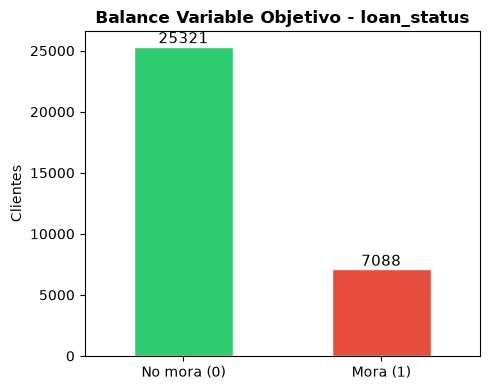

In [23]:
# Balance de loan_status (variable objetivo clasificacion)
conteo = df_modelo['loan_status'].value_counts()
pct = (conteo / len(df_modelo) * 100).round(1)

print('=== BALANCE LOAN_STATUS ===')
print(f'  No mora (0): {conteo.get(0, 0)} ({pct.get(0, 0)}%)')
print(f'  Mora    (1): {conteo.get(1, 0)} ({pct.get(1, 0)}%)')

fig, ax = plt.subplots(figsize=(5, 4))
conteo.rename({0: 'No mora (0)', 1: 'Mora (1)'}).plot(
    kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white'
)
ax.set_title('Balance Variable Objetivo - loan_status', fontweight='bold')
ax.set_ylabel('Clientes')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### Conclusion - Seccion 1: Preparacion de Datos

Pipeline completado:

- **Unidad de analisis:** cliente unico (solicitante). Duplicados completos eliminados.
- **Imputacion:** mediana global para `person_emp_length`; mediana por grupo (`loan_grade`) para `loan_int_rate`.
- **Data leakage:** analizado; no se detectaron variables con informacion post-otorgamiento.
- **Encoding:** `cb_person_default_on_file` binario; `loan_grade` ordinal (A=1..F=6); `person_home_ownership` y `loan_intent` con One-Hot.
- **Outliers:** removidos registros con `person_age > 100` o `person_emp_length > 60`.
- **Dataset final:** numerico, sin nulos, listo para modelado.

> Siguiente: Seccion 2 - Exploracion Visual y Diagnostico.

---
## 2. Exploración Visual y Diagnóstico

Esta sección clasifica todas las variables y estudia patrones, asimetrías, desbalance de clases y riesgos de negocio antes del modelado. Para facilitar la lectura de los gráficos se conserva una copia con las categorías originales.

### 2.1 Clasificación de variables

| Variable | Clasificación | Descripción |
|---|---|---|
| `person_age` | Numérica discreta | Edad del solicitante en años |
| `person_income` | Numérica continua | Ingreso anual |
| `person_home_ownership` | Categórica nominal | Tipo de vivienda: alquiler, hipoteca, propia u otra |
| `person_emp_length` | Numérica continua | Antigüedad laboral en años |
| `loan_intent` | Categórica nominal | Finalidad del crédito |
| `loan_grade` | Categórica ordinal | Grado de riesgo crediticio de A a G |
| `loan_amnt` | Numérica continua | Monto solicitado |
| `loan_int_rate` | Numérica continua | Tasa de interés porcentual |
| `loan_status` | Binaria | 0: no mora; 1: mora |
| `loan_percent_income` | Numérica continua | Proporción del ingreso comprometida en el préstamo |
| `cb_person_default_on_file` | Binaria | Antecedente de incumplimiento: Y/N |
| `cb_person_cred_hist_length` | Numérica discreta | Antigüedad del historial crediticio en años |



In [25]:
# Copia interpretable para exploración: categorías originales y mismos filtros de calidad
display(df.columns)
df_categorias = df.copy()
df_categorias = df_categorias[(df_categorias['person_age'] <= 100) & (df_categorias['person_emp_length'] <= 60)].copy()
df_categorias['estado_credito'] = df_categorias['loan_status'].map({0: 'No mora', 1: 'Mora'})
df_categorias['loan_grade'] = pd.Categorical(
    df_categorias['loan_grade'], categories=list('ABCDEFG'), ordered=True
)

assert df_categorias.isna().sum().sum() == 0, 'Existen nulos pendientes en df_categorias'
print(f'Dataset por Categorias: # de  {df_categorias.shape[0]} solicitudes x # {df_categorias.shape[1]} variables')
df_categorias.head()

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Dataset por Categorias: # de  32409 solicitudes x # 13 variables


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,estado_credito
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,No mora
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,Mora
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,Mora
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,Mora
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,Mora


### 2.2 Gráfico 1 — Desbalance de la variable objetivo

Permite visualizar si la mora y  no mora tienen tamaños similares.

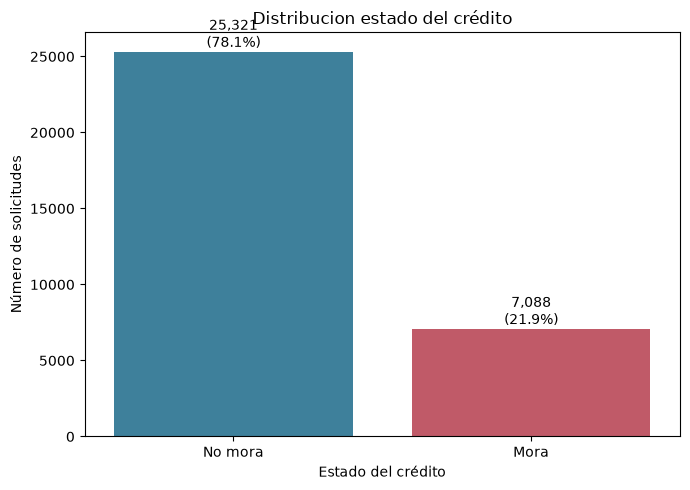

In [29]:
orden_estado = ['No mora', 'Mora']
paleta_estado = {'No mora': '#2E86AB', 'Mora': '#D1495B'}

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_categorias, x='estado_credito', order=orden_estado, palette=paleta_estado, hue='estado_credito', legend=False)
total = len(df_categorias)
for barra in ax.patches:
    cantidad = int(barra.get_height())
    ax.text(barra.get_x() + barra.get_width()/2, cantidad, f'{cantidad:,}\n({cantidad/total:.1%})', ha='center', va='bottom')
plt.title('Distribucion estado del crédito')
plt.xlabel('Estado del crédito')
plt.ylabel('Número de solicitudes')
plt.tight_layout()
plt.show()

### 2.3 Gráfico 2 — Distribución del ingreso según mora

El histograma permite observar asimetría, concentración y diferencias entre los grupos.

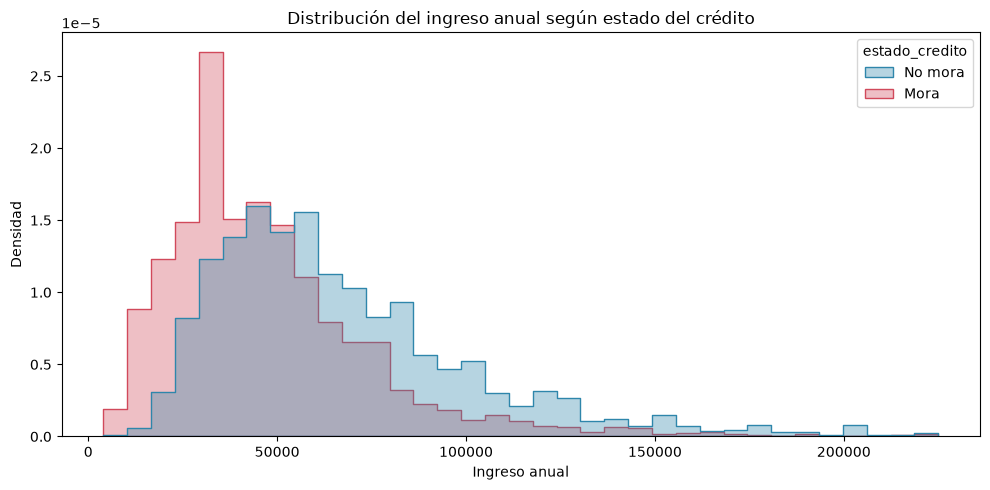

In [30]:
limite_ingreso = df_categorias['person_income'].quantile(0.99)
df_ingreso_plot = df_categorias[df_categorias['person_income'] <= limite_ingreso]

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df_ingreso_plot, x='person_income', hue='estado_credito',
    hue_order=orden_estado, palette=paleta_estado, bins=35,
    stat='density', common_norm=False, element='step', alpha=0.35
)
plt.title('Distribución del ingreso anual según estado del crédito')
plt.xlabel('Ingreso anual')
plt.ylabel('Densidad')
plt.tight_layout()
plt.show()

### 2.4 Gráfico 3 — Carga del préstamo respecto al ingreso

Compara la proporción del ingreso comprometida por el préstamo entre clientes con y sin mora. Valores altos representan una mayor carga financiera, por tanto, es un posible riesgo de negocio.

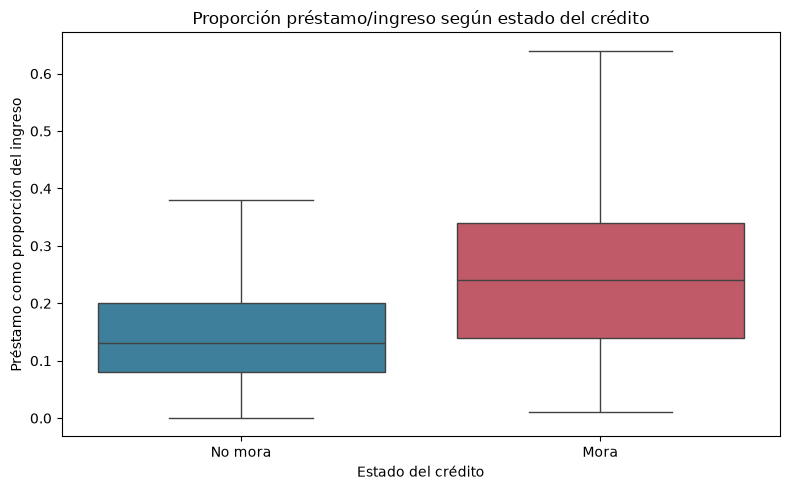

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_categorias, x='estado_credito', y='loan_percent_income',
    order=orden_estado, palette=paleta_estado, hue='estado_credito', legend=False,
    showfliers=False
)
plt.title('Proporción préstamo/ingreso según estado del crédito')
plt.xlabel('Estado del crédito')
plt.ylabel('Préstamo como proporción del ingreso')
plt.tight_layout()
plt.show()

### 2.5 Gráfico 4 — Tasa de mora por calificación crediticia

Muestra el porcentaje de mora dentro de cada calificación de credito. Permite comprobar si hay un aumento aumento del riesgo y detectar segmentos que requieren políticas más estrictas.

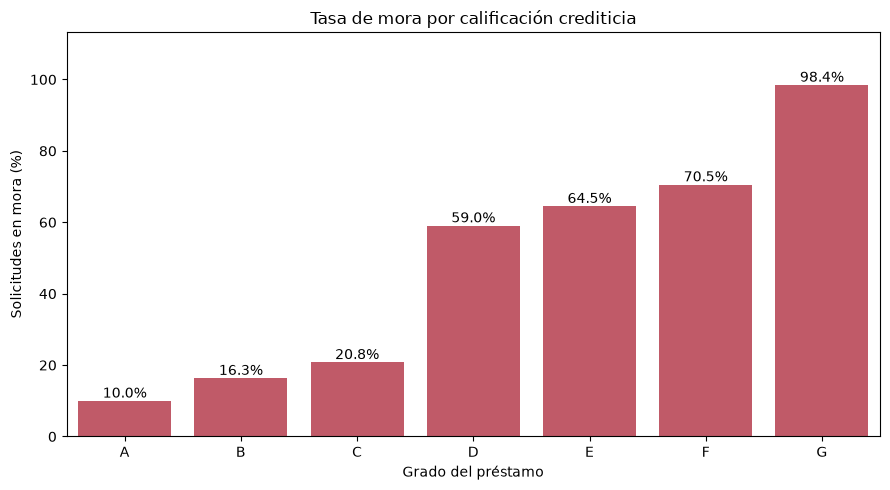

,loan_grade,solicitudes,tasa_mora_pct
0,A,10702,9.96
1,B,10384,16.32
2,C,6436,20.76
3,D,3619,59.05
4,E,963,64.49
5,F,241,70.54
6,G,64,98.44


In [33]:
mora_grado = (
    df_categorias.groupby('loan_grade', observed=False)['loan_status']
    .agg(tasa_mora='mean', solicitudes='size')
    .reset_index()
)
mora_grado['tasa_mora_pct'] = mora_grado['tasa_mora'] * 100

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=mora_grado, x='loan_grade', y='tasa_mora_pct', color='#D1495B')
for barra in ax.patches:
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(), f'{barra.get_height():.1f}%', ha='center', va='bottom')
plt.title('Tasa de mora por calificación crediticia')
plt.xlabel('Grado del préstamo')
plt.ylabel('Solicitudes en mora (%)')
plt.ylim(0, max(mora_grado['tasa_mora_pct']) * 1.15)
plt.tight_layout()
plt.show()
mora_grado[['loan_grade', 'solicitudes', 'tasa_mora_pct']].round(2)

### 2.6 Gráfico 5 — Matriz de correlación

Resume las relaciones lineales entre las variables numéricas y `loan_status`.

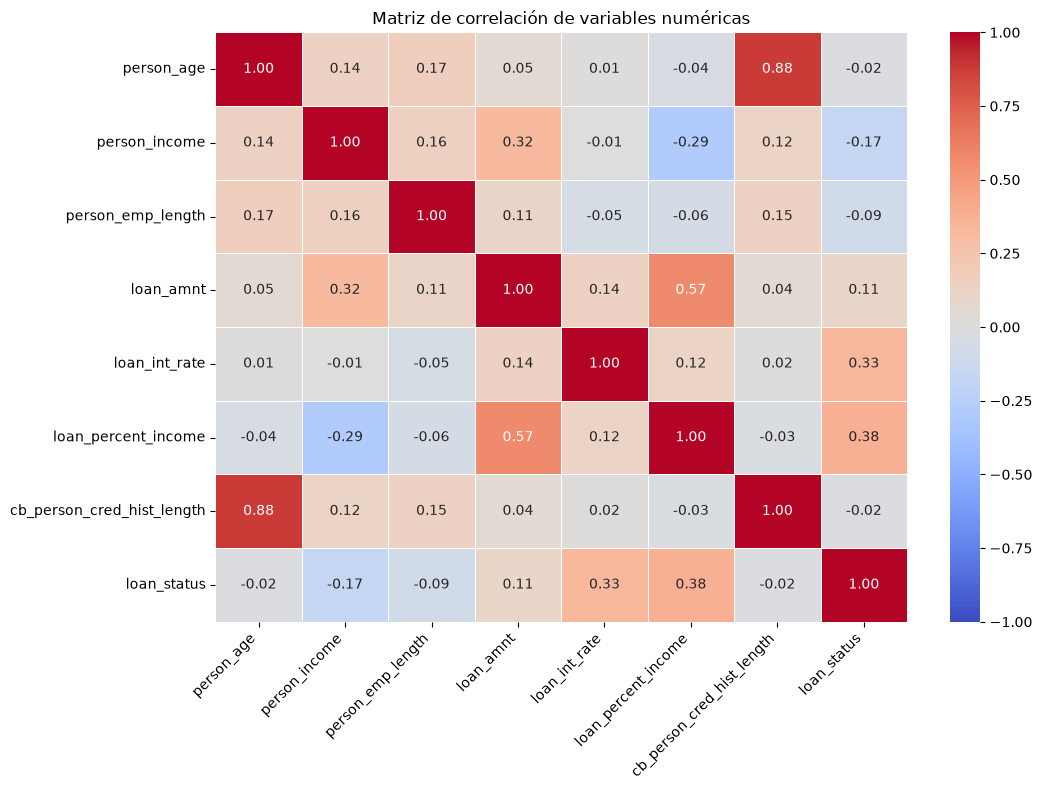

In [34]:
variables_numericas = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'loan_status'
]
corr = df_categorias[variables_numericas].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5
)
plt.title('Matriz de correlación de variables numéricas')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.7 Diagnóstico cuantitativo

Las siguientes tablas respaldan la lectura de los gráficos.

In [35]:
diagnostico_estado = (
    df_categorias.groupby('estado_credito')
    .agg(
        solicitudes=('loan_status', 'size'),
        ingreso_mediano=('person_income', 'median'),
        monto_mediano=('loan_amnt', 'median'),
        tasa_interes_mediana=('loan_int_rate', 'median'),
        proporcion_ingreso_mediana=('loan_percent_income', 'median')
    )
    .reindex(orden_estado)
    .round(2)
)
diagnostico_estado

,solicitudes,ingreso_mediano,monto_mediano,tasa_interes_mediana,proporcion_ingreso_mediana
estado_credito,,,,,
No mora,25321,60000.0,8000.0,10.65,0.13
Mora,7088,41655.0,9600.0,13.48,0.24
